In [90]:
# ==========================================
# 🎓 FRAUD RISK PREDICTION SYSTEM
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

from imblearn.over_sampling import SMOTE

In [91]:
# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv('/content/PS_20174392719_1491204439457_log.csv')
df = df.sample(n=100000, random_state=42)


print("📊 Dataset Loaded!")
print(df.head())
print(df.columns)

📊 Dataset Loaded!
         step      type      amount     nameOrig  oldbalanceOrg  \
3737323   278   CASH_IN   330218.42   C632336343       20866.00   
264914     15   PAYMENT    11647.08  C1264712553       30370.00   
85647      10   CASH_IN   152264.21  C1746846248      106589.00   
5899326   403  TRANSFER  1551760.63   C333676753           0.00   
2544263   206   CASH_IN    78172.30   C813403091     2921331.58   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
3737323       351084.42   C834976624       452419.57       122201.15        0   
264914         18722.92   M215391829            0.00            0.00        0   
85647         258853.21  C1607284477       201303.01        49038.80        0   
5899326            0.00  C1564353608      3198359.45      4750120.08        0   
2544263      2999503.88  C1091768874       415821.90       337649.60        0   

         isFlaggedFraud  
3737323               0  
264914                0  
85647         

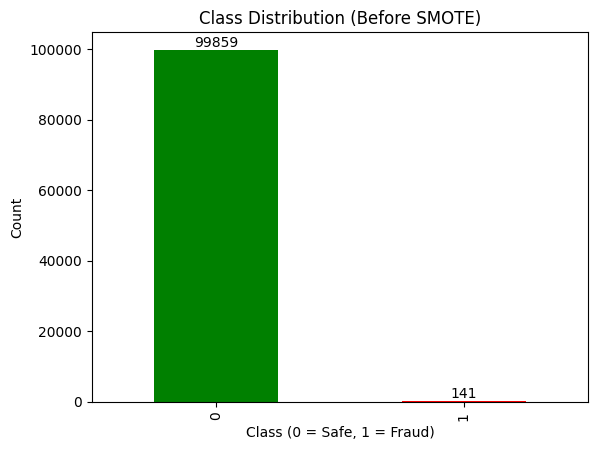

In [92]:
# ==========================================
# 2A. CLASS DISTRIBUTION
# ==========================================

plt.figure()

counts = df['isFraud'].value_counts()
counts.plot(kind='bar', color=['green', 'red'])

plt.title("Class Distribution (Before SMOTE)")
plt.xlabel("Class (0 = Safe, 1 = Fraud)")
plt.ylabel("Count")

# Add labels on bars
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [93]:
# ==========================================
# 2B. DATA PREPROCESSING
# ==========================================

# Drop useless columns
df = df.drop(['nameOrig', 'nameDest'], axis=1)

# Encode type
df = pd.get_dummies(df, columns=['type'], drop_first=True)

# Feature engineering
df['balance_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['dest_balance_diff'] = df['newbalanceDest'] - df['oldbalanceDest']
df['error_balance_orig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['error_balance_dest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
# ==========================================
# REMOVE LEAKAGE FEATURES (IMPORTANT FIX)
# ==========================================

df = df.drop(['error_balance_orig', 'error_balance_dest'], axis=1)

# Drop leakage
df = df.drop(['isFlaggedFraud'], axis=1)

# Remove NaN
df = df.dropna(subset=['isFraud'])

print("✅ Preprocessing Done!")

✅ Preprocessing Done!


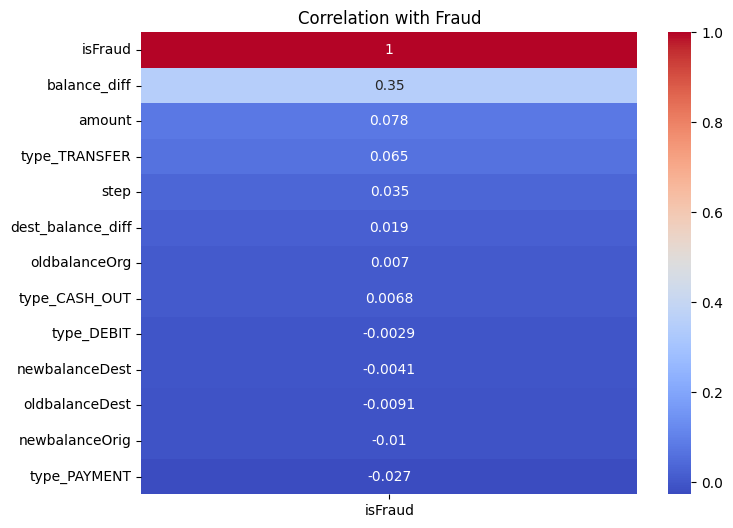

In [94]:
# ==========================================
# 3A. CORRELATION WITH TARGET
# ==========================================

plt.figure(figsize=(8,6))

corr = df.corr()['isFraud'].sort_values(ascending=False)

sns.heatmap(corr.to_frame(), annot=True, cmap='coolwarm')

plt.title("Correlation with Fraud")
plt.show()

In [95]:
# ==========================================
# 3B. FEATURES & TARGET
# ==========================================

X = df.drop('isFraud', axis=1)
y = df['isFraud']

print("Before SMOTE:\n", y.value_counts())

Before SMOTE:
 isFraud
0    99859
1      141
Name: count, dtype: int64


In [96]:
# ==========================================
# 4. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check shapes and distribution
print("X_train shape:", X_train.shape)
print("y_train distribution:\n", y_train.value_counts())

X_train shape: (80000, 12)
y_train distribution:
 isFraud
0    79887
1      113
Name: count, dtype: int64


In [97]:
# ==========================================
# SCALING
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [98]:
# ==========================================
# 5. HANDLE IMBALANCE USING SMOTE
# ==========================================

smote = SMOTE(random_state=42)

# Apply SMOTE on SCALED data
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:\n", pd.Series(y_train_smote).value_counts())

After SMOTE:
 isFraud
0    79887
1    79887
Name: count, dtype: int64


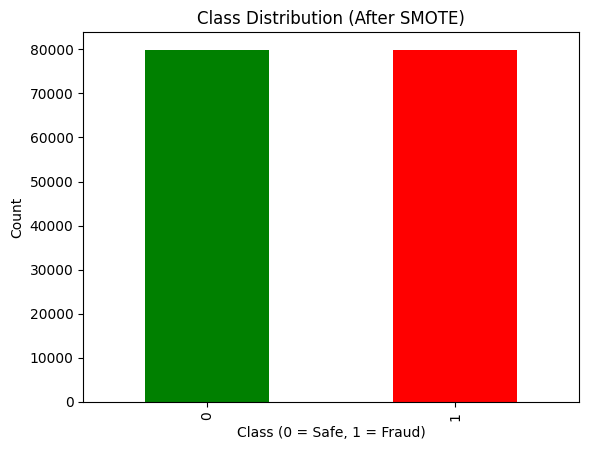

In [99]:
# ==========================================
# 6A. CLASS DISTRIBUTION AFTER SMOTE
# ==========================================

plt.figure()

pd.Series(y_train_smote).value_counts().plot(kind='bar', color=['green', 'red'])

plt.title("Class Distribution (After SMOTE)")
plt.xlabel("Class (0 = Safe, 1 = Fraud)")
plt.ylabel("Count")

plt.show()

In [100]:
print("🚀 Training Logistic Regression...")

lr = LogisticRegression(max_iter=500)

lr.fit(X_train_smote, y_train_smote)

print("✅ Logistic Regression Done!")

🚀 Training Logistic Regression...
✅ Logistic Regression Done!


In [101]:
# ==========================================
# 7B. TRAIN RANDOM FOREST
# ==========================================

print("🚀 Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

print("✅ Random Forest Done!")

🚀 Training Random Forest...
✅ Random Forest Done!


In [102]:
# ==========================================
# 7C. TRAIN GRADIENT BOOSTING
# ==========================================

print("🚀 Training Gradient Boosting...")

gb = GradientBoostingClassifier(
    n_estimators=50,
    max_depth=3
)

gb.fit(X_train_smote, y_train_smote)

print("✅ Gradient Boosting Done!")

🚀 Training Gradient Boosting...
✅ Gradient Boosting Done!


In [103]:
# ==========================================
# 8A. MODEL EVALUATION
# ==========================================

lr_pred = lr.predict(X_test_scaled)
rf_pred = rf.predict(X_test_scaled)
gb_pred = gb.predict(X_test_scaled)

print("📊 MODEL EVALUATION\n")

print("🔹 Accuracy:")
print("LR:", accuracy_score(y_test, lr_pred))
print("RF:", accuracy_score(y_test, rf_pred))
print("GB:", accuracy_score(y_test, gb_pred))

print("\n📋 Random Forest Report:\n")
print(classification_report(y_test, rf_pred))

📊 MODEL EVALUATION

🔹 Accuracy:
LR: 0.95725
RF: 0.99335
GB: 0.9809

📋 Random Forest Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     19972
           1       0.16      0.86      0.27        28

    accuracy                           0.99     20000
   macro avg       0.58      0.93      0.63     20000
weighted avg       1.00      0.99      1.00     20000



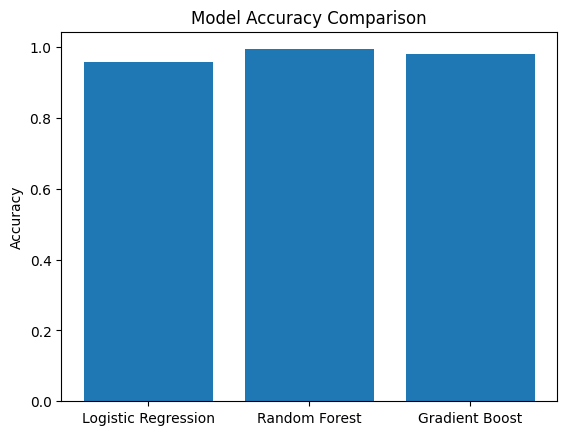

In [104]:
# ==========================================
# 8B. MODEL ACCURACY COMPARISON
# ==========================================

models = ['Logistic Regression', 'Random Forest', 'Gradient Boost']
accuracy = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, gb_pred)
]

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [105]:
# ==========================================
# MODEL COMPARISON + RANKING
# ==========================================

print("\n📊 INDIVIDUAL MODEL PERFORMANCE\n")

models = {
    "Logistic Regression": lr.predict(X_test_scaled),
    "Random Forest": rf.predict(X_test_scaled),
    "Gradient Boosting": gb.predict(X_test_scaled)
}

results = {}

for name, pred in models.items():
    acc = accuracy_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results[name] = f1

    print(f"🔹 {name}")
    print(f"   Accuracy: {acc:.4f}")
    print(f"   Recall  : {rec:.4f}")
    print(f"   F1 Score: {f1:.4f}\n")


# ==========================================
# MODEL RANKING
# ==========================================

sorted_models = sorted(results.items(), key=lambda x: x[1], reverse=True)

print("🏆 MODEL RANKING (Best → Worst):\n")

for i, (model, score) in enumerate(sorted_models, 1):
    print(f"{i}. {model} → F1 Score: {score:.4f}")

best_model = sorted_models[0][0]

print(f"\n✅ BEST MODEL: {best_model}")


📊 INDIVIDUAL MODEL PERFORMANCE

🔹 Logistic Regression
   Accuracy: 0.9573
   Recall  : 0.9643
   F1 Score: 0.0594

🔹 Random Forest
   Accuracy: 0.9933
   Recall  : 0.8571
   F1 Score: 0.2652

🔹 Gradient Boosting
   Accuracy: 0.9809
   Recall  : 0.9286
   F1 Score: 0.1198

🏆 MODEL RANKING (Best → Worst):

1. Random Forest → F1 Score: 0.2652
2. Gradient Boosting → F1 Score: 0.1198
3. Logistic Regression → F1 Score: 0.0594

✅ BEST MODEL: Random Forest


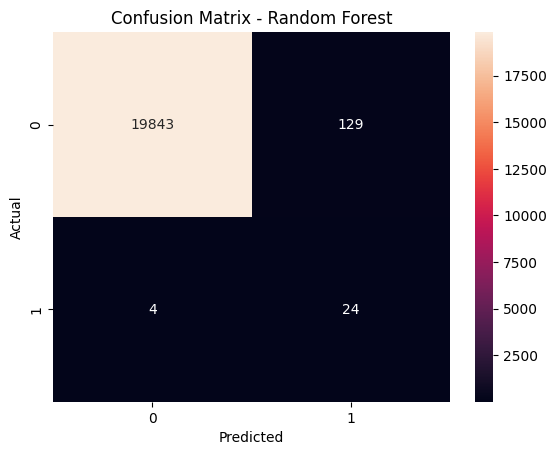

In [106]:
# ==========================================
# 8C: CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, rf_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

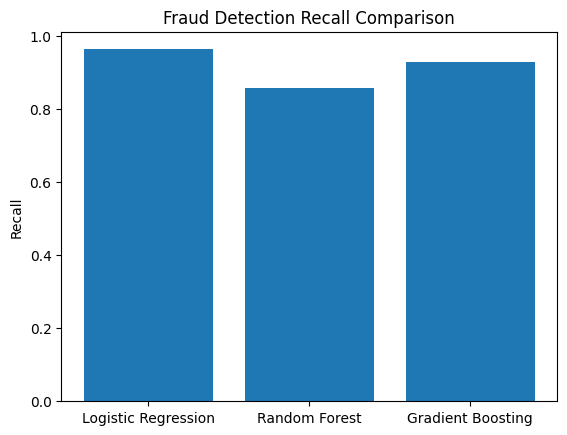

In [107]:
# ==========================================
# 8D. FRAUD RECALL COMPARISON
# ==========================================

model_names = ["Logistic Regression", "Random Forest", "Gradient Boosting"]

recall = [
    recall_score(y_test, lr_pred),
    recall_score(y_test, rf_pred),
    recall_score(y_test, gb_pred)
]

plt.figure()
plt.bar(model_names, recall)
plt.title("Fraud Detection Recall Comparison")
plt.ylabel("Recall")
plt.show()

In [108]:
# ==========================================
# 9A. FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance.head(10))

              Feature  Importance
10       balance_diff    0.364848
2       oldbalanceOrg    0.149993
3      newbalanceOrig    0.114080
1              amount    0.104094
9       type_TRANSFER    0.080881
11  dest_balance_diff    0.052000
8        type_PAYMENT    0.032434
0                step    0.029876
5      newbalanceDest    0.028151
4      oldbalanceDest    0.024820


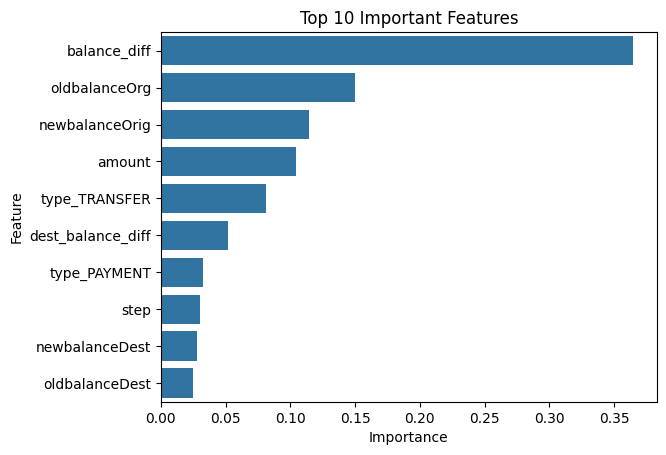

In [109]:
# ==========================================
# 9B. FEATURE IMPORTANCE PLOT
# ==========================================

plt.figure()
sns.barplot(x='Importance', y='Feature', data=importance.head(10))
plt.title("Top 10 Important Features")
plt.show()

In [88]:
# ==========================================
# 10. USER INPUT
# ==========================================

print("\n📌 ENTER TRANSACTION DETAILS:\n")

user_data = {}

raw_features = [
    'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'
]

for feature in raw_features:
    val = float(input(f"Enter {feature}: "))
    user_data[feature] = val

user_df = pd.DataFrame([user_data])

# Feature engineering
user_df['balance_diff'] = user_df['oldbalanceOrg'] - user_df['newbalanceOrig']
user_df['dest_balance_diff'] = user_df['newbalanceDest'] - user_df['oldbalanceDest']
user_df['error_balance_orig'] = user_df['oldbalanceOrg'] - user_df['amount'] - user_df['newbalanceOrig']
user_df['error_balance_dest'] = user_df['oldbalanceDest'] + user_df['amount'] - user_df['newbalanceDest']

# Align columns
user_df = user_df[X.columns]


📌 ENTER TRANSACTION DETAILS:

Enter step: 10
Enter amount: 90000
Enter oldbalanceOrg: 90000
Enter newbalanceOrig: 0
Enter oldbalanceDest: 0
Enter newbalanceDest: 90000
Enter type_CASH_OUT: 0
Enter type_DEBIT: 0
Enter type_PAYMENT: 0
Enter type_TRANSFER: 1


In [89]:
# ==========================================
# 11. FRAUD PREDICTION (FINAL FIXED)
# ==========================================

# Step 1: Align columns
user_df = user_df[X.columns]

# Step 2: Scale input (IMPORTANT)
user_scaled = scaler.transform(user_df)

# Step 3: Predict using best model (Random Forest)
prob = rf.predict_proba(user_scaled)[0][1]

# Debug (keep this for clarity)
print(f"Raw Probability: {prob}")

# Step 4: Threshold (you can tune this later)
threshold = 0.01

prediction = "FRAUD 🚨" if prob > threshold else "SAFE ✅"

print("\n" + "="*50)
print("🔍 FRAUD ANALYSIS RESULT")
print("="*50)

print(f"Prediction: {prediction}")
print(f"Fraud Risk Probability: {prob*100:.2f}%")

Raw Probability: 0.6076234405293838

🔍 FRAUD ANALYSIS RESULT
Prediction: FRAUD 🚨
Fraud Risk Probability: 60.76%
